In [10]:
# src/data/preprocessor.py
import os
import torch
import requests
import json
import time
import gzip
import pandas as pd
import numpy as np
import osmnx as ox
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional
from sklearn.preprocessing import MinMaxScaler
from shapely.geometry import Polygon, MultiPolygon, mapping
# from src.config import THU_DUC_BOUNDS, PROCESSED_DIR

In [11]:
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
THU_DUC_BOUNDS = {
    'north': 10.8700, 'south': 10.7300, 'east': 106.8200, 'west': 106.6800
}
print(PROJECT_DIR)
print(THU_DUC_BOUNDS)

d:\2_Workspace\4_Nam_4\1_Hoc_ky_251\1_Do_An_Chuyen_Nganh\HCM_UTL\src
{'north': 10.87, 'south': 10.73, 'east': 106.82, 'west': 106.68}


In [ ]:

class TomTomTrafficDataCollector:
    """
    Thu thập dữ liệu giao thông thực tế từ TomTom Traffic Stats API
    """
    def __init__(self, api_key: str):
        self.api_key = api_key
        self.base_url = "https://api.tomtom.com/traffic/trafficstats"
        
    def create_area_analysis_job(self, geometry: dict, date_from: str, date_to: str,
                                 job_name: str="Thu_Duc_Traffic_Analysis",
                                 time_sets: List[Dict] = None) -> Optional[str]:
        """
        Tạo job phân tích giao thông cho một khu vực
        
        Args:
            geometry: GeoJSON MultiPolygon/Polygon
            date_from: Ngày bắt đầu (YYYY-MM-DD)
            date_to: Ngày kết thúc (YYYY-MM-DD)
            job_name: Tên job
            time_sets: Các time sets để phân tích
            
        Returns:
            job_id nếu thành công, None nếu thất bại
        """
        
        if time_sets is None:
            # Tạo time sets mặc định cho giờ cao điểm và bình thường
            time_sets = [
                {
                    "name": "Morning Peak",
                    "timeGroups": [
                        {
                            "days": ["MON", "TUE", "WED", "THU", "FRI"],
                            "times": ["07:00-09:00"]
                        }
                    ]
                },
                {
                    "name": "Evening Peak",
                    "timeGroups": [
                        {
                            "days": ["MON", "TUE", "WED", "THU", "FRI"],
                            "times": ["17:00-19:00"]
                        }
                    ]
                },
                {
                    "name": "Off Peak",
                    "timeGroups": [
                        {
                            "days": ["MON", "TUE", "WED", "THU", "FRI"],
                            "times": ["10:00-16:00"]
                        }
                    ]
                },
                {
                    "name": "Weekend",
                    "timeGroups": [
                        {
                            "days": ["SAT", "SUN"],
                            "times": ["00:00-24:00"]
                        }
                    ]
                }
            ]
            
        request_body = {
            "jobName": job_name,
            "distanceUnit": "KILOMETERS",
            "network": {
                "name": "Thu Duc Network",
                "geometry": geometry,
                "timeZoneId": "Asia/Ho_Chi_Minh",
                "frcs": ["0", "1", "2", "3", "4", "5", "6", "7"],
                "probeSource": "ALL"
            },
            "dateRange": {
                    "name": f"{date_from} to {date_to}",
                    "from": date_from,
                    "to": date_to,
            },
            "timeSets": time_sets
        }
        
        url = f"{self.base_url}/areaanalysis/1?key={self.api_key}"
        
        try:
            response = requests.post(
                url,
                headers={"Content-Type": "application/json"},
                json=request_body,
                timeout=30
            )
            
            if response.status_code == 200:
                result = response.json()
                if result.get("responseStatus") == "OK":
                    job_id = result.get("jobId")
                    print(f"✅ Job created successfully! Job ID: {job_id}")
                    print(f"   Messages: {result.get('messages')}")
                    return job_id
                else:
                    print(f"❌ Job creation failed: {result}")
                    return None
            elif response.status_code == 400:
                result = response.json()
                # Nếu job đã tồn tại thì lấy luôn jobId từ response
                if "already created" in str(result.get("messages")) and result.get("jobId"):
                    job_id = result["jobId"]
                    print(f"ℹ️ Job already exists. Using existing Job ID: {job_id}")
                    return job_id
                else:
                    print(f"❌ API Error: {response.status_code} - {result}")
                    return None
            else:
                print(f"❌ API Error: {response.status_code} - {response.text}")
                return None
        except Exception as e:    
            print(f"❌ Exception when creating job: {e}")
            return None
    
    def check_job_status(self, job_id: str) -> dict:
        """
        Kiểm tra trạng thái job
        """
        url = f"{self.base_url}/status/1/{job_id}?key={self.api_key}"
        
        try:
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                return response.json()
            else:
                print(f"❌ Status check error: {response.status_code}")
                return {}
        except Exception as e:
            print(f"❌ Exception when checking status: {e}")
            return {}
    
    def wait_for_job_completion(self, job_id: str, max_wait_minutes: int = 60) -> Optional[dict]:
        """
        Chờ job hoàn thành và trả về kết quả
        """
        print(f"⏳ Waiting for job {job_id} to complete...")
        
        start_time = time.time()
        max_wait_seconds = max_wait_minutes * 60
        while True:
            elapsed = time.time() - start_time
            if elapsed >= max_wait_seconds:
                print(f"⏰ Timeout after {max_wait_minutes} minutes")
                return None
            
            status = self.check_job_status(job_id)
            job_state = status.get("jobState", "UNKNOWN")
            
            print(f"   Status: {job_state} (elapsed: {int(elapsed)}s)")
            
            if job_state == "DONE":
                print("Job completed successfully!")
                return status
            elif job_state in ["ERROR", "REJECTED", "CANCELLED"]:
                print(f"Job failed with state: {job_state}")
                return None
            elif job_state == "NEED_CONFIRMATION":
                print("Job needs manual confirmation")
                sample_url = status.get("sampleDetailsUrl")
                if sample_url:
                    print(f"   Sample details: {sample_url}")
                return status
            
            # Chờ trước khi check lại
            time.sleep(30)
    
    def download_results(self, job_id: str):
        """
        Download kết quả JSON từ job đã hoàn thành
        """
        import os
        from urllib.parse import urlparse
        
        PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
        output_dir = os.path.join(PROJECT_DIR, "data", "raw", "tomtom_stats")
        
        os.makedirs(output_dir, exist_ok=True)
        
        status = self.check_job_status(job_id)
        
        if status.get("jobState") != "DONE":
            print(f"⚠️  Job is not DONE yet: {status.get('jobState')}")
            return None
        
        urls = status.get("urls", [])
        if not urls:
            print("❌ No result URLs found")
            return None
        
        json_url = None
        for url in urls:
            filename = urlparse(url).path
            if filename.endswith(".json"):
                json_url = url
                break

        if not json_url:
            print("⚠️ No JSON/GeoJSON result")
            return None
    
        print(f"📥 Downloading results from: {json_url}")
        
        try:
            response = requests.get(json_url, timeout=120)
            if response.status_code == 200:
                # Decompress gzip
                content = response.content
                try:
                    content = gzip.decompress(response.content)
                except OSError:
                    pass
                result_data = json.loads(content.decode("utf-8"))
                
                # Save to file
                output_file = os.path.join(output_dir, f"job_{job_id}_results.json")
                with open(output_file, 'w', encoding="utf-8") as f:
                    json.dump(result_data, f, indent=2, ensure_ascii=False)
                
                print(f"💾 Results saved to: {output_file}")
                return result_data
            else:
                print(f"❌ Download failed: {response.status_code}")
                return None
        except Exception as e:
            print(f"❌ Exception during download: {e}")
            return None

In [ ]:
class TrafficDataPreprocessor:
    """
    Tiền xử lý dữ liệu giao thông từ OpenStreetMap và TomTom API
    cho dự án T-GCN phân tích giao thông TP.HCM
    """
    def __init__(self, tomtom_api_key: str =  None):
        """
        Khởi tạo preprocessor
        
        Args:
            tomtom_api_key: API key của TomTom
        """
        self.tomtom_api_key = tomtom_api_key
        self.tomtom_collector = TomTomTrafficDataCollector(tomtom_api_key) if tomtom_api_key else None
        self.graph = None
        self.nodes_df = pd.DataFrame()
        self.edges_df = pd.DataFrame()
        self.traffic_data = {}
        self.tomtom_results = None

    def extract_osm_data(self):
        """
        Trích xuất dữ liệu đường bộ từ OpenStreetMap
        """
        print("📍 Đang tải dữ liệu OpenStreetMap cho Thủ Đức...")
        try:
            # Tạo polygon cho khu vực Thủ Đức
            place_name = "Thủ Đức, Ho Chi Minh City, Vietnam"
            
            # Lấy graph mạng từ OSM
            self.graph = ox.graph_from_place(
                place_name,
                network_type='drive',
                simplify=True
            )
            
            print(f"✅ Đã tải {len(self.graph.nodes)} nút và {len(self.graph.edges)} cạnh")
            
            # Chuyển đổi sang DataFrame
            self._convert_graph_to_dataframes()
        except Exception as e:
            print(f"Lỗi khi tải dữ liệu OSM: {e}")
            # Fallback: sử dụng bounding box
            self._load_osm_by_bbox()
    
    def _load_osm_by_bbox(self):
        """Tải dữ liệu OSM bằng bounding box"""
        print("🔄 Đang thử với bounding box...")
        self.graph = ox.graph_from_bbox(
            north=THU_DUC_BOUNDS['north'],
            south=THU_DUC_BOUNDS['south'],
            east=THU_DUC_BOUNDS['east'],
            west=THU_DUC_BOUNDS['west'],
            network_type='drive',
            simplify=True
        )
        
        print(f"✅ Đã tải {len(self.graph.nodes)} nút và {len(self.graph.edges)} cạnh")
        self._convert_graph_to_dataframes()

    def _convert_graph_to_dataframes(self):
        """Chuyển đổi NetworkX graph sang DataFrame"""
        # Nodes Data
        nodes_data = []
        for node_id, data in self.graph.nodes(data=True):
            nodes_data.append({
                "node_id": node_id,
                "lat": data['y'],
                "lon": data['x'],
                'osmid': data.get('osmid', node_id)
            })
        
        self.nodes_df = pd.DataFrame(nodes_data)
        
        # Edges DataFrame
        edges_data = []
        for u, v, key, data in self.graph.edges(data=True, keys=True):
            # print(u, v, key, data)
            edges_data.append({
                'from_node': u,
                'to_node': v,
                'edge_key': key,
                'length': data.get('length', 0),
                'highway': data.get('highway', 'unclassified'),
                'maxspeed': self._parse_maxspeed(data.get('maxspeed')),
                'lanes': self._parse_lanes(data.get('lanes')),
                'osmid': data.get('osmid', f"{u}_{v}_{key}")
            })
        self.edges_df = pd.DataFrame(edges_data)
        
        print(f"📊 Nodes DataFrame: {len(self.nodes_df)} hàng")
        print(f"📊 Edges DataFrame: {len(self.edges_df)} hàng")

    def _parse_maxspeed(self, maxspeed):
        """Parse maxspeed từ OSM data"""
        if maxspeed is None:
            return 50
        
        if isinstance(maxspeed, list):
            maxspeed = maxspeed[0]
        
        try:
            speed = int(str(maxspeed).replace("km/h", "").strip())
            return speed
        except:
            return 50
    
    def _parse_lanes(self, lanes):
        """Parse số làn đường"""
        if lanes is None:
            return 2
        
        if isinstance(lanes, list):
            lanes = lanes[0]
        
        try:
            return int(lanes)
        except: 
            return 2
        
    def create_bbox_polygon(self) -> dict:
        """
        Tạo GeoJSON Polygon cho khu vực Thủ Đức
        """
        
        coords = [[
            [THU_DUC_BOUNDS['west'], THU_DUC_BOUNDS['south']],
            [THU_DUC_BOUNDS['east'], THU_DUC_BOUNDS['south']],
            [THU_DUC_BOUNDS['east'], THU_DUC_BOUNDS['north']],
            [THU_DUC_BOUNDS['west'], THU_DUC_BOUNDS['north']],
            [THU_DUC_BOUNDS['west'], THU_DUC_BOUNDS['south']]
        ]]
        
        return {
            "type": "Polygon",
            "coordinates": coords
        }
        
    def collect_tomtom_traffic_data(self, date_from: str, date_to: str,
                                    auto_wait: bool = True) -> Optional[dict]:
        """
        Thu thập dữ liệu giao thông thực tế từ TomTom API
        
        Args:
            date_from: Ngày bắt đầu (YYYY-MM-DD)
            date_to: Ngày kết thúc (YYYY-MM-DD)
            auto_wait: Tự động chờ job hoàn thành
        """
        if not self.tomtom_collector:
            print("❌ Không có TomTom API key. Sử dụng dữ liệu mô phỏng.")
            return None
        
        print("🚀 Bắt đầu thu thập dữ liệu từ TomTom API...")
        
        # Tạo geometry cho request
        geometry = self.create_bbox_polygon()
        
        # Tạo job
        job_id = self.tomtom_collector.create_area_analysis_job(
            geometry=geometry,
            date_from=date_from,
            date_to=date_to,
            job_name=f"ThuDuc_Traffic_{date_from}_to_{date_to}"
        )
        
        if not job_id:
            return None
        
        if auto_wait:
            # Chờ job hoàn thành
            status = self.tomtom_collector.wait_for_job_completion(job_id)
            
            if status and status.get("jobState") == "DONE":
                # Download kết quả
                results = self.tomtom_collector.download_results(job_id)
                self.tomtom_results = results
                return results
            
        return {"job_id": job_id, "status": "pending"}
    
    def parse_tomtom_results(self, results: dict = None) -> pd.DataFrame:
        """
        Parse kết quả từ TomTom API thành DataFrame
        
        Returns:
            DataFrame chứa dữ liệu segment với traffic stats
        """
        if results is None:
            print("❌ Không có dữ liệu TomTom để parse")
            return pd.DataFrame()
        
        print("🔄 Parsing TomTom results...")
        
        segment_data = []
        
        network = results.get('network', {})
        segments = network.get('segmentResults', [])
        
        for segment in segments:
            base_info = {
                'segment_id': segment.get('segmentId'),
                'new_segment_id': segment.get('newSegmentId'),
                'speed_limit': segment.get('speedLimit'),
                'frc': segment.get('frc'),
                'street_name': segment.get('streetName'),
                'distance': segment.get('distance'),
                'shape': segment.get('shape')
            }
            
            # Parse traffic data cho mỗi timeset
            for time_result in segment.get('segmentTimeResults', []):
                row = base_info.copy()
                row.update({
                    'time_set': time_result.get('timeSet'),
                    'date_range': time_result.get('dateRange'),
                    'harmonic_avg_speed': time_result.get('harmonicAverageSpeed'),
                    'median_speed': time_result.get('medianSpeed'),
                    'average_speed': time_result.get('averageSpeed'),
                    'std_dev_speed': time_result.get('standardDeviationSpeed'),
                    'sample_size': time_result.get('sampleSize'),
                    'avg_travel_time': time_result.get('averageTravelTime'),
                    'median_travel_time': time_result.get('medianTravelTime'),
                    'travel_time_ratio': time_result.get('travelTimeRatio')
                })
                segment_data.append(row)
        
        df = pd.DataFrame(segment_data)
        print(f"✅ Parsed {len(df)} segment records")
        
        return df

    def get_major_intersections(self, min_degree: int = 3) -> pd.DataFrame:
        """
        Lấy các nút giao thông quan trọng (có độ >= min_degree)
        
        Args:
            min_degree: Độ tối thiểu của nút (số đường giao nhau)
        
        Returns:
            DataFrame chứa các nút giao thông quan trọng
        """
        print(f"🔍 Các nút giao thông quan trọng (độ >= {min_degree})...")
        
        # Tính degree cho mỗi node
        degrees = dict(self.graph.degree())
        
        # Lọc nodes có degree cao
        important_nodes = []
        for node_id, degree in degrees.items():
            if degree >= min_degree:
                node_data = self.graph.nodes[node_id]
                important_nodes.append({
                    'node_id': node_id,
                    'lat': node_data['y'],
                    'lon': node_data['x'],
                    'degree': degree,
                    'osmid': node_data.get('osmid', node_id)
                })
        
        important_nodes_df = pd.DataFrame(important_nodes)
        print(f"✅ Tìm thấy {len(important_nodes_df)} nút giao thông quan trọng")
        
        return important_nodes_df.sort_values('degree', ascending=False)
    
    def create_adjacency_matrix(self, important_nodes: pd.DataFrame) -> torch.Tensor:
        """
        Tạo ma trận kề cho T-GCN từ các nút quan trọng
        """
        print("🔗 Tạo ma trận kề...")
        
        node_ids = important_nodes['node_id'].tolist()
        n_nodes = len(node_ids)
        
        # Tạo mapping từ node_id sang index
        node_to_index = {node_id: i for i, node_id in enumerate(node_ids)}
        
        # Khởi tạo ma trận kề
        adj_matrix = torch.zeros((n_nodes, n_nodes))
        
        # Điền ma trận dự trên edges
        for _, edge in self.edges_df.iterrows():
            from_node, to_node = edge['from_node'], edge['to_node']
            
            if from_node in node_to_index and to_node in node_to_index:
                from_idx, to_idx = node_to_index[from_node], node_to_index[to_node]
                
                # Trọng số dựa trên độ dài đường (nghịch đảo)
                weight = 1.0 / (1.0 + edge['length'] / 1000) # Normalize by km
                
                adj_matrix[from_idx, to_idx] = weight
                adj_matrix[to_idx, from_idx] = weight
        
        # Điền ma trận dựa trên edges
        print(f"✅ Ma trận kề {n_nodes}x{n_nodes} đã được tạo")
        
        return torch.FloatTensor(adj_matrix) 
    
    def create_feature_matrix_from_tomtom(self, important_nodes: pd.DataFrame,
                                          tomtom_df: pd.DataFrame) -> torch.Tensor:
        """
        Tạo ma trận đặc trưng cho T-GCN từ dữ liệu giao thông
        """
        print("📋 Tạo ma trận đặc trưng từ TomTom data...")
        
        # Group by time_set để có các time periods
        time_sets = sorted(tomtom_df['time_set'].unique())
        node_ids = important_nodes['node_id'].tolist()
        
        # Initialize features: (nodes, time_steps, features)
        features = []
        
        for node_id in node_ids:
            node_features = []
            
            for ts in time_sets:
                # Filter segments gần node này (có thể cải thiện bằng spatial join)
                # Đơn giản hóa: lấy trung bình của tất cả segments trong time_set
                ts_data = tomtom_df[tomtom_df['time_set'] == ts]
                
                if len(ts_data) > 0:
                    # Features: [avg_speed, median_speed, std_dev, travel_time_ratio, sample_size]
                    avg_speed = ts_data['average_speed'].mean() / 100.0 # Normalize
                    median_speed = ts_data['median_speed'].mean() / 100.0
                    std_dev = ts_data['std_dev_speed'].mean() / 50.0
                    tt_ratio = ts_data['travel_time_ratio'].mean() / 3.0
                    sample_size = np.log1p(ts_data['sample_size'].mean()) / 10.0
                    
                    feature_vector = [avg_speed, median_speed, std_dev, tt_ratio, sample_size]
                else:
                    feature_vector = [0.5, 0.5, 0.1, 0.33, 0.0]
                
                node_features.append(feature_vector)
            
            features.append(node_features)
        
        feature_tensor = torch.FloatTensor(features)
        print(f"✅ Ma trận đặc trưng {feature_tensor.shape} đã được tạo")
        
        return feature_tensor
    
    def save_processed_data(self, important_nodes: pd.DataFrame,
                            adj_matrix: torch.Tensor,
                            features: torch.Tensor,
                            tomtom_df: pd.DataFrame = None,
                            output_dir: str = "processed"):
        """
        Lưu dữ liệu đã xử lý
        """
        PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
        output_dir = os.path.join(PROJECT_DIR, "data", output_dir)
        os.makedirs(output_dir, exist_ok=True)
        
        important_nodes.to_csv(f"{output_dir}/important_nodes.csv", index=False)
        self.edges_df.to_csv(f"{output_dir}/edges.csv", index=False)
        
        if tomtom_df is not None and len(tomtom_df) > 0:
            tomtom_df.to_csv(f"{output_dir}/tomtom_traffic_data.csv", index=False)
        
        torch.save(adj_matrix, f"{output_dir}/adjacency_matrix.pt")
        torch.save(features, f"{output_dir}/node_features.pt")
        
        metadata = {
            'num_nodes': len(important_nodes),
            'num_features': features.shape[-1],
            'time_steps': features.shape[1],
            'feature_names': ['avg_speed', 'median_speed', 'std_dev_speed', 'travel_time_ratio', 'log_sample_size'],
            'bounds': THU_DUC_BOUNDS,
            'created_at': datetime.now().isoformat(),
            'data_source': 'TomTom API' if tomtom_df is not None else 'Simulated'
        }
        
        with open(f"{output_dir}/metadata.json", 'w', encoding="utf-8") as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
        
        print(f"💾 Đã lưu tất cả dữ liệu tại thư mục '{output_dir}'")

In [14]:
pre = TrafficDataPreprocessor()
pre.extract_osm_data()
print("Graph info:", pre.graph)
print("Số nút:", len(pre.graph.nodes))
print("Số cạnh:", len(pre.graph.edges))
print("DataFrame nodes:", pre.nodes_df.head())
print("DataFrame edges:", pre.edges_df.head())

📍 Đang tải dữ liệu OpenStreetMap cho Thủ Đức...
✅ Đã tải 1005 nút và 2270 cạnh
📊 Nodes DataFrame: 1005 hàng
📊 Edges DataFrame: 2270 hàng
Graph info: MultiDiGraph with 1005 nodes and 2270 edges
Số nút: 1005
Số cạnh: 2270
DataFrame nodes:      node_id        lat         lon      osmid
0  366371768  10.847943  106.767221  366371768
1  366373335  10.846049  106.750576  366373335
2  366377163  10.845707  106.765317  366377163
3  366377394  10.848511  106.769310  366377394
4  366378393  10.847141  106.768383  366378393
DataFrame edges:    from_node      to_node  edge_key      length      highway  maxspeed  lanes  \
0  366371768    366401628         0  111.893276  residential        50      2   
1  366371768    366458086         0  143.628567  residential        50      2   
2  366371768    366477012         0  114.740519  residential        50      2   
3  366371768  11813524962         0  207.961921  residential        50      2   
4  366373335   8814518226         0   48.951544  residentia

In [15]:
# pre.fetch_tomtom_flow(52.41072, 4.84239, api_key="ivTlgJMC4yCOce67YYEzvEFUDpvJEmVR")

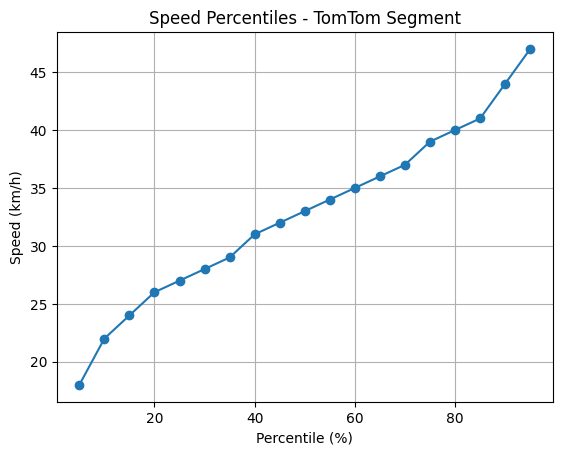

In [16]:
import matplotlib.pyplot as plt

percentiles = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95]
speeds = [18,22,24,26,27,28,29,31,32,33,34,35,36,37,39,40,41,44,47]

plt.plot(percentiles, speeds, marker='o')
plt.title("Speed Percentiles - TomTom Segment")
plt.xlabel("Percentile (%)")
plt.ylabel("Speed (km/h)")
plt.grid(True)
plt.show()

In [17]:
def main():
    """
    Pipeline tiền xử lý hoàn chỉnh với TomTom API
    """
    print("🚀 Bắt đầu tiền xử lý dữ liệu giao thông Thủ Đức cho T-GCN")
    print("="*70)
    #  BƯỚC 1: Nhập API key (hoặc để None để dùng dữ liệu mô phỏng)
    TOMTOM_API_KEY = os.getenv("TOMTOM_TRAFFIC_STATS_API_KEY")  # Thay bằng API key thật của bạn
    print(TOMTOM_API_KEY)
    
    preprocessor = TrafficDataPreprocessor(tomtom_api_key=TOMTOM_API_KEY)
    
    # BƯỚC 2: Trích xuất dữ liệu OpenStreetMap
    preprocessor.extract_osm_data()
    
    # BƯỚC 3: Tìm các nút giao thông quan trọng
    important_nodes = preprocessor.get_major_intersections(min_degree=3)
    print(f"\nTop 10 nút quan trọng nhất:")
    print(important_nodes.head(10)[['node_id', 'lat', 'lon', 'degree']])
    
    # BƯỚC 4: Thu thập dữ liệu TomTom (nếu có API key)
    tomtom_df = None
    
    if TOMTOM_API_KEY:
        print("\n" + "="*70)
        print("📡 Thu thập dữ liệu từ TomTom API...")
        
        # Ví dụ: lấy dữ liệu tháng trước
        date_from = "2024-08-01"
        date_to   = "2024-08-31"

        results = preprocessor.collect_tomtom_traffic_data(date_from, date_to)
        
        if results and 'jobId' not in results:  # Results downloaded
            tomtom_df = preprocessor.parse_tomtom_results(results)
            print(f"\n✅ Thu thập được {len(tomtom_df)} segment records từ TomTom")
    else:
        print("\n⚠️  Không có TomTom API key - bỏ qua thu thập dữ liệu thực")
        print("💡 Để sử dụng TomTom API:")
        print("   1. Đăng ký miễn phí tại: https://developer.tomtom.com/")
        print("   2. Lấy API key")
        print("   3. Thay thế TOMTOM_API_KEY trong code")

    # BƯỚC 5: Tạo ma trận cho T-GCN
    print("\n" + "="*70)
    print("🔧 Tạo ma trận cho T-GCN...")
        
    adj_matrix = preprocessor.create_adjacency_matrix(important_nodes)
    
    if tomtom_df is not None and len(tomtom_df) > 0:
        # Sử dụng dữ liệu TomTom thực
        features = preprocessor.create_feature_matrix_from_tomtom(important_nodes, tomtom_df)
    else:
        # Fallback: tạo dữ liệu mẫu
        print("   Sử dụng dữ liệu mẫu do không có dữ liệu TomTom...")
        n_nodes = len(important_nodes)
        n_timesteps = 4  # Morning peak, Evening peak, Off peak, Weekend
        n_features = 5
        features = torch.rand(n_nodes, n_timesteps, n_features) * 0.5 + 0.25
    
    print(f"\n📊 Kết quả cuối cùng:")
    print(f"   - Số nút quan trọng: {len(important_nodes)}")
    print(f"   - Ma trận kề: {adj_matrix.shape}")
    print(f"   - Ma trận đặc trưng: {features.shape}")
    print(f"   - Features: avg_speed, median_speed, std_dev, travel_time_ratio, log_sample_size")
    
    # BƯỚC 6: Lưu dữ liệu
    print("\n" + "="*70)
    preprocessor.save_processed_data(important_nodes, adj_matrix, features, tomtom_df)
    
    print("\n✅ Hoàn thành tiền xử lý dữ liệu!")
    print("📁 Dữ liệu đã được lưu trong thư mục 'processed_data'")
    print("\n🔜 Bước tiếp theo: Xây dựng mô hình T-GCN với dữ liệu này")
    print("\n💡 Tip: Nếu đang chờ TomTom job hoàn thành, có thể dùng:")
    print("   preprocessor.tomtom_collector.check_job_status(job_id)")
    print("   preprocessor.tomtom_collector.download_results(job_id)")
    
if __name__ == "__main__":
    main()

🚀 Bắt đầu tiền xử lý dữ liệu giao thông Thủ Đức cho T-GCN
locV6Jddi6AUHajUWrQvporhfGsk43M9
📍 Đang tải dữ liệu OpenStreetMap cho Thủ Đức...
✅ Đã tải 1005 nút và 2270 cạnh
📊 Nodes DataFrame: 1005 hàng
📊 Edges DataFrame: 2270 hàng
🔍 Các nút giao thông quan trọng (độ >= 3)...
✅ Tìm thấy 653 nút giao thông quan trọng

Top 10 nút quan trọng nhất:
        node_id        lat         lon  degree
0     366371768  10.847943  106.767221       8
105   366479316  10.844953  106.766695       8
212  3118891564  10.837124  106.745581       8
211  3118891549  10.836853  106.744002       8
197  3100059736  10.837606  106.751099       8
188  2947068401  10.836060  106.764165       8
173  2947068323  10.838204  106.761177       8
170  2947068314  10.834773  106.754679       8
161  2947068272  10.833257  106.758939       8
148  2947067529  10.833933  106.760674       8

📡 Thu thập dữ liệu từ TomTom API...
🚀 Bắt đầu thu thập dữ liệu từ TomTom API...
✅ Job created successfully! Job ID: 7863381
   Messages: ['